## 导入模块与配置

In [1]:
import sys
from pathlib import Path

# 将 src 目录加入 Python 路径
src_path = Path.cwd() / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# 导入自定义模块
from config import OUTPUT_DIR
from data_loader import load_orders
from preprocessing import preprocess_orders
from metrics import compute_user_stats, compute_rfm, compute_category_preference
from repurchase_retention import (
    compute_repeat_purchase_rate,
    compute_monthly_repeat_rate,
    compute_repurchase_cycle,
    plot_repurchase_cycle_distribution,
    compute_retention_matrix
)
from lifetime import compute_ltv_top10, identify_lost_users
from report_exporter import export_user_lifecycle_report

## 加载数据并初步审查

In [2]:
# 1. 读取数据
users_orders = load_orders()

print("users_orders 前5行:")
print(users_orders.head())
print("\n数据概览:")
print(users_orders.info())

users_orders 前5行:
   order_id  user_id order_date  amount product_category payment_method
0      2610      739 2022-01-29  652.13               服装            信用卡
1      1813     1094 2022-06-06  640.28               美妆            信用卡
2      3760      934 2022-04-26  454.42               美妆             微信
3      5298     1342 2022-05-05  513.74               服装            支付宝
4      8077      356 2022-04-13  962.30               食品            信用卡

数据概览:
<class 'pandas.DataFrame'>
RangeIndex: 10544 entries, 0 to 10543
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          10544 non-null  int64         
 1   user_id           10544 non-null  int64         
 2   order_date        10544 non-null  datetime64[us]
 3   amount            10433 non-null  float64       
 4   product_category  10544 non-null  str           
 5   payment_method    10348 non-null  str           
dtypes: dateti

## 预处理：缺失值、异常值、时间特征

In [3]:
# 2. 数据清洗与特征提取
users_orders = preprocess_orders(users_orders)

print("清洗后数据形状:", users_orders.shape)
print("\n时间特征示例:")
print(users_orders[['order_date', 'order_year', 'order_month', 'order_dayofweek', 'order_quarter']].head())

清洗后数据形状: (10220, 10)

时间特征示例:
  order_date order_year order_month  order_dayofweek order_quarter
0 2022-01-29       2022     2022-01                5        2022Q1
1 2022-06-06       2022     2022-06                0        2022Q2
2 2022-04-26       2022     2022-04                1        2022Q2
3 2022-05-05       2022     2022-05                3        2022Q2
4 2022-04-13       2022     2022-04                2        2022Q2


## 用户基础统计

In [4]:
# 3. 用户基础统计（第4题）
user_detail = compute_user_stats(users_orders)
print("用户基础统计（前5行）:")
print(user_detail.head())

用户基础统计（前5行）:
        first_order_date last_order_date  total_orders  total_amount  \
user_id                                                                
1             2022-01-13      2022-04-19             9       3352.58   
2             2022-04-21      2022-06-22             9       5092.16   
3             2022-06-08      2022-08-15             5       2426.87   
4             2022-02-03      2022-06-02             5       2486.64   
5             2022-02-08      2022-02-23             3        782.87   

         avg_order_value  
user_id                   
1             372.508889  
2             565.795556  
3             485.374000  
4             497.328000  
5             260.956667  


## RFM 分层

In [5]:
# 4. RFM 分层（第5题）
rfm_df = compute_rfm(user_detail)
print("RFM 分层结果（前5行）:")
print(rfm_df.head())

RFM 分层结果（前5行）:
         user_id R_score F_score M_score  RFM_total segment
user_id                                                    
1              1       2       4       3          9     中价值
2              2       3       4       4         11     高价值
3              3       4       2       2          8     中价值
4              4       2       2       2          6     低价值
5              5       1       1       1          3     低价值


## 商品类别偏好

In [6]:
# 5. 商品类别偏好（第6题）
prefer_df = compute_category_preference(users_orders)
print("用户最偏好商品类别（前5行）:")
print(prefer_df.head())

用户最偏好商品类别（前5行）:
   user_id top_category  category_amount
0        1           食品          1085.58
1        2           服装          2034.92
2        3           服装          1701.65
3        4           服装          1378.51
4        5           食品           552.60


## 复购率

In [7]:
# 6. 复购率（第7题）
repeat_rate = compute_repeat_purchase_rate(user_detail)
print(f"整体复购率: {repeat_rate}")

monthly_repeat = compute_monthly_repeat_rate(users_orders)
print("\n月复购率:")
print(monthly_repeat)

整体复购率: 91.05%

月复购率:
   order_month  month_fugou_rate
0      2022-01         60.207612
1      2022-02         61.842105
2      2022-03         58.099688
3      2022-04         54.082999
4      2022-05         51.330798
5      2022-06         49.204406
6      2022-07         43.589744
7      2022-08         34.062500
8      2022-09         26.351351
9      2022-10         10.144928
10     2022-11         11.111111
11     2022-12          0.000000


## 复购周期分析

全部用户复购周期中位数：12.2 天
全部用户复购周期均值：14.9 天


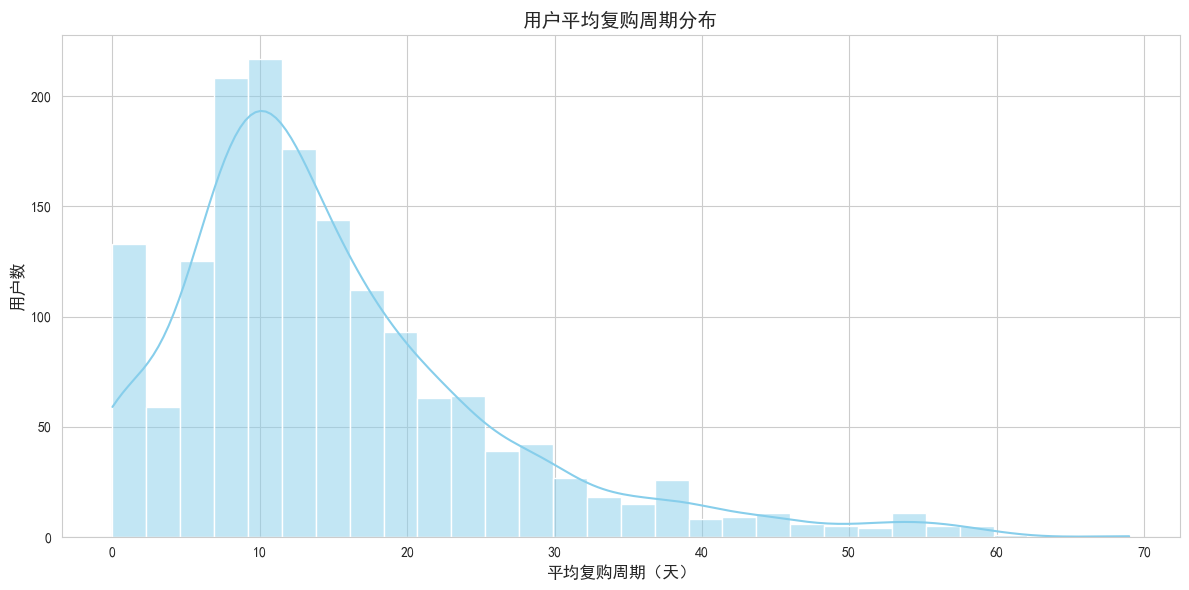

In [8]:
# 7. 复购周期（第8题）
cycle_df = compute_repurchase_cycle(users_orders, user_detail)
global_median = cycle_df['avg'].median()
global_mean = cycle_df['avg'].mean()
print(f"全部用户复购周期中位数：{global_median:.1f} 天")
print(f"全部用户复购周期均值：{global_mean:.1f} 天")

# 绘制分布直方图（与 notebook 一致）
plot_repurchase_cycle_distribution(cycle_df)

## 用户留存曲线

In [9]:
# 8. 留存曲线（第9题）
retention_pivot = compute_retention_matrix(users_orders)
print("用户留存透视表（前6个月）:")
print(retention_pivot)

用户留存透视表（前6个月）:
pianyi_liang          1          2          3          4         5         6
first_cohort                                                                
2022-01       60.207612  57.093426  28.373702  12.802768  2.768166  1.038062
2022-02       62.411348  59.574468  32.624113  21.631206  7.092199  1.418440
2022-03       64.119601  50.830565  31.229236  14.285714  5.647841  0.332226
2022-04       64.802632  51.644737  30.592105  16.447368  5.592105  0.986842
2022-05       63.225806  49.354839  28.064516  12.258065  6.129032  0.967742
2022-06       64.784053  53.488372  30.232558  15.614618  4.651163  0.996678


## LTV 前十用户

In [10]:
# 9. LTV 前十用户（第10题）
ltv_top10 = compute_ltv_top10(user_detail)
print("LTV 前十用户:")
print(ltv_top10)

LTV 前十用户:
      user_id       LTV  active_days  avg_daily_spend
983      1108  12832.76          181        70.899227
900      1009  11361.95          138        82.332971
1295     1461  10249.49           72       142.354028
1165     1313  10100.55          133        75.943985
783       881   9897.56          158        62.642785
1662     1864   9604.84           52       184.708462
678       759   9509.09          104        91.433558
37         41   9324.67           91       102.468901
998      1126   8975.02          147        61.054558
1491     1672   8894.27          118        75.375169


## 流失用户识别

In [11]:
# 10. 流失用户特征（第11题）
lost_summary = identify_lost_users(user_detail, users_orders)
print("流失用户特征汇总:")
print(lost_summary)

流失用户特征汇总:
   lost_user  lost_rate  avg_total_orders  avg_total_amount  \
0       1767  98.880806          5.660441       2888.159445   

  main_product_category  
0                    美妆  


## 导出 Excel 报告

In [12]:
# 11. 生成 Excel 报告（第12题）
# 构造 sheets 字典，与 notebook 完全一致
sheets = {
    '用户基础统计': user_detail,
    'RFM 分层结果': rfm_df,
    '商品类别偏好': prefer_df,
    '月复购率': monthly_repeat,
    '用户留存透视表': retention_pivot.reset_index(),   # 透视表需 reset_index 才能无索引写入
    '流失用户特征汇总': lost_summary
}

export_user_lifecycle_report(sheets)
print(f"报告已保存至 {OUTPUT_DIR} 目录")

用户生命周期报告已保存为: F:\Anaconda3_Pandas\项目\新项目\outputs\user_lifecycle_20260514.xlsx
报告已保存至 F:\Anaconda3_Pandas\项目\新项目\outputs 目录
